# AAI

In [1]:
import pandas as pd
ruta_archivo_aai = "/home/haydeeperuyero/FastANI/miel_ani_aai_caai/aai.tsv"

# Lread file to a Dataframe
df = pd.read_csv(ruta_archivo_aai, sep="\t", header=0)


In [2]:
df

,ID 1,ID 2,Label 1,Label 2,AAI,CDS count 1,CDS count 2,Matched count,Proteome cov.,ID param.,Cov. param.
0,573237050,573237050,A_jinshanensis.sub-aerogenes.fasta,A_jinshanensis.sub-aerogenes.fasta,100.000000,1561,1561,1557,0.997438,0.4,0.5
1,573237050,824902336,A_jinshanensis.sub-aerogenes.fasta,F_fructivorans.strain-DSM-20203.fasta,59.925977,1561,1351,691,0.474588,0.4,0.5
2,573237050,75270993,A_jinshanensis.sub-aerogenes.fasta,92_Scapto_009.fasta,63.978514,1561,1202,740,0.535650,0.4,0.5
3,573237050,953307900,A_jinshanensis.sub-aerogenes.fasta,42_Melli_004.fasta,63.643175,1561,1163,718,0.527166,0.4,0.5
4,573237050,1052490636,A_jinshanensis.sub-aerogenes.fasta,39_Melli_barcode04.fasta,61.529146,1561,1664,808,0.501085,0.4,0.5
...,...,...,...,...,...,...,...,...,...,...,...
1291,131356186,274891167,L_senioris.DSM-24302.fasta,89_Scapto_001.fasta,61.833180,1594,1173,651,0.470546,0.4,0.5
1292,131356186,1014861920,L_senioris.DSM-24302.fasta,45_Melli_016.fasta,62.799128,1594,1659,688,0.422994,0.4,0.5
1293,131356186,272623363,L_senioris.DSM-24302.fasta,40_Melli_029.fasta,63.159417,1594,1544,669,0.426386,0.4,0.5
1294,131356186,915029192,L_senioris.DSM-24302.fasta,41_Melli_001.fasta,63.578033,1594,1673,783,0.479339,0.4,0.5


In [3]:
import os 
def limpiar_nombre(ruta):
    nombre = os.path.basename(ruta)  # Obtiene solo el nombre del archivo
    return nombre.replace(".fasta", "")  # Elimina la extensión .fna

# Aplicar la función a las dos primeras columnas
df.iloc[:, 2] = df.iloc[:, 2].apply(limpiar_nombre)
df.iloc[:, 3] = df.iloc[:, 3].apply(limpiar_nombre)

df

,ID 1,ID 2,Label 1,Label 2,AAI,CDS count 1,CDS count 2,Matched count,Proteome cov.,ID param.,Cov. param.
0,573237050,573237050,A_jinshanensis.sub-aerogenes,A_jinshanensis.sub-aerogenes,100.000000,1561,1561,1557,0.997438,0.4,0.5
1,573237050,824902336,A_jinshanensis.sub-aerogenes,F_fructivorans.strain-DSM-20203,59.925977,1561,1351,691,0.474588,0.4,0.5
2,573237050,75270993,A_jinshanensis.sub-aerogenes,92_Scapto_009,63.978514,1561,1202,740,0.535650,0.4,0.5
3,573237050,953307900,A_jinshanensis.sub-aerogenes,42_Melli_004,63.643175,1561,1163,718,0.527166,0.4,0.5
4,573237050,1052490636,A_jinshanensis.sub-aerogenes,39_Melli_barcode04,61.529146,1561,1664,808,0.501085,0.4,0.5
...,...,...,...,...,...,...,...,...,...,...,...
1291,131356186,274891167,L_senioris.DSM-24302,89_Scapto_001,61.833180,1594,1173,651,0.470546,0.4,0.5
1292,131356186,1014861920,L_senioris.DSM-24302,45_Melli_016,62.799128,1594,1659,688,0.422994,0.4,0.5
1293,131356186,272623363,L_senioris.DSM-24302,40_Melli_029,63.159417,1594,1544,669,0.426386,0.4,0.5
1294,131356186,915029192,L_senioris.DSM-24302,41_Melli_001,63.578033,1594,1673,783,0.479339,0.4,0.5


In [4]:
# Obtain unique IDs for query and reference 
ids_unicos = pd.unique(df[['Label 1', 'Label 2']].values.ravel())

# Create an empty DataFrame with the unique IDs as colnames and rownames, start at 0
matriz_aai = pd.DataFrame(0, index=ids_unicos, columns=ids_unicos)

# Fill the matrix with the ani values
for _, row in df.iterrows():
    matriz_aai.at[row['Label 1'], row['Label 2']] = row['AAI']

/tmp/ipykernel_2014117/2395588489.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '59.925977' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  matriz_aai.at[row['Label 1'], row['Label 2']] = row['AAI']
/tmp/ipykernel_2014117/2395588489.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '63.978514' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  matriz_aai.at[row['Label 1'], row['Label 2']] = row['AAI']
/tmp/ipykernel_2014117/2395588489.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '63.643175' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  matriz_aai.at[row['Label 1'], row['Label 2']] = row['AAI']
/tmp/ipykernel_2

In [5]:
# Show the matrix
matriz_aai

,A_jinshanensis.sub-aerogenes,F_fructivorans.strain-DSM-20203,92_Scapto_009,42_Melli_004,39_Melli_barcode04,40_Melli_barcode03,47_Melli_001,45_Melli_020,F_sanfranciscensis.DSM-20451,51_Scapto_004,...,92_Scapto_002,23_Scapto_001,46_Melli_022,89_Scapto_002,90_Scapto_012,89_Scapto_001,45_Melli_016,40_Melli_029,41_Melli_001,L_senioris.DSM-24302
A_jinshanensis.sub-aerogenes,100.000000,59.925977,63.978514,63.643175,61.529146,61.504280,61.618919,61.617426,58.578358,63.828562,...,63.684225,63.545576,61.942330,63.849038,63.811346,63.506634,61.952270,62.207038,61.583006,59.094239
F_fructivorans.strain-DSM-20203,59.925977,100.000000,62.301347,62.225758,63.076893,63.162038,63.137056,63.074905,68.119369,62.134158,...,62.363538,62.397077,62.866035,62.214245,62.224143,62.269863,62.861079,63.232057,63.114639,62.730725
92_Scapto_009,63.978514,62.301347,100.000000,79.219819,64.387051,64.458068,64.446402,64.388875,60.592758,99.789728,...,79.314933,79.356768,64.259670,99.743666,99.774317,79.185525,64.259599,64.548974,64.404872,61.421165
42_Melli_004,63.643175,62.225758,79.219819,100.000000,64.794834,64.684335,64.825322,64.813192,60.598454,79.541007,...,99.283411,99.205566,64.521429,79.287815,79.229157,99.167415,64.490757,64.798051,64.856678,61.928560
39_Melli_barcode04,61.529146,63.076893,64.387051,64.794834,100.000000,99.584734,99.586124,99.601513,61.645013,64.256951,...,64.822524,64.782198,72.056855,64.260542,64.283687,64.745309,72.020636,68.642951,99.727599,63.506429
40_Melli_barcode03,61.504280,63.162038,64.458068,64.684335,99.588516,100.000000,99.532423,99.552861,61.774934,64.301040,...,64.721241,64.684279,72.009849,64.310023,64.303151,64.648824,71.943424,68.541594,99.663612,63.600899
47_Melli_001,61.618919,63.137056,64.446402,64.825322,99.586124,99.532423,100.000000,99.823229,61.728525,64.215901,...,64.874524,64.793059,71.911523,64.261356,64.290999,64.763232,71.834789,68.804428,99.739509,63.550000
45_Melli_020,61.617426,63.074905,64.388875,64.813192,99.601513,99.552861,99.823229,100.000000,61.700000,64.225403,...,64.805762,64.731346,71.993100,64.264651,64.254307,64.709224,71.970721,68.846312,99.739006,63.555619
F_sanfranciscensis.DSM-20451,58.578358,68.119369,60.592758,60.598454,61.645013,61.774934,61.728525,61.700000,100.000000,60.407833,...,60.640732,60.596009,61.789865,60.440616,60.493897,60.614531,61.786036,62.066309,61.747368,61.378415
51_Scapto_004,63.828562,62.134158,99.789728,79.541007,64.256951,64.301040,64.215901,64.225403,60.407833,100.000000,...,79.428932,79.513870,64.209458,99.787715,99.692985,79.378935,64.232173,64.507632,64.265575,61.374162


In [6]:
matriz_aai.index

Index(['A_jinshanensis.sub-aerogenes', 'F_fructivorans.strain-DSM-20203',
       '92_Scapto_009', '42_Melli_004', '39_Melli_barcode04',
       '40_Melli_barcode03', '47_Melli_001', '45_Melli_020',
       'F_sanfranciscensis.DSM-20451', '51_Scapto_004',
       'A_apinorum.strain-Fhon13', 'L_Lactobacillus.spSy-1',
       'A_timberlakei.strain-HV-12', 'Nicoliella_spurrieriana_SGEP1_A5',
       'Nicoliella_lavandulae_Es01', 'A_micheneri.strain-Hlig3',
       'A_kunkeei.DSM-12361', 'A_ozensis.DSM-23829', 'F_florum.DSM-22689',
       'L_kosoi.strain-NBRC-113063', 'A_jinshanensis.strain-HSLZ-75',
       '22_Melli_029', '90_Scapto_barcode20', 'F_lindneri.DSM-20690',
       'A_jinshanensis.brasiliensis', 'A_quenuiae.strain-HV-6',
       '92_Scapto_002', '23_Scapto_001', '46_Melli_022', '89_Scapto_002',
       '90_Scapto_012', '89_Scapto_001', '45_Melli_016', '40_Melli_029',
       '41_Melli_001', 'L_senioris.DSM-24302'],
      dtype='object')

In [7]:
orden = ['40_Melli_029', '45_Melli_016', '46_Melli_022', 
         'L_Lactobacillus.spSy-1',
         'Nicoliella_spurrieriana_SGEP1_A5', 'Nicoliella_lavandulae_Es01',
         '22_Melli_029','40_Melli_barcode03', '45_Melli_020','47_Melli_001','39_Melli_barcode04','41_Melli_001','90_Scapto_barcode20',
         'A_jinshanensis.brasiliensis',
         'A_jinshanensis.strain-HSLZ-75',
         'A_jinshanensis.sub-aerogenes', 
         '51_Scapto_004','89_Scapto_002','90_Scapto_012','92_Scapto_009',
         '42_Melli_004','23_Scapto_001', '89_Scapto_001','92_Scapto_002',
         'A_kunkeei.DSM-12361']
          
matriz_aai = matriz_aai.reindex(index=orden, columns=orden)       

In [8]:
rename_dict = {
    '40_Melli_029':'40_Melli.029', 
    '45_Melli_016':'45_Melli.016', 
    '46_Melli_022':'46_Melli.022',
    'L_Lactobacillus.spSy-1':'Lactobacillus sp. Sy-1',
    'Nicoliella_spurrieriana_SGEP1_A5': 'N. spurrieriana SGEP1_A5', 
    'Nicoliella_lavandulae_Es01': 'N. lavandulae Es01',
    '22_Melli_029':'22_Melli.029',
    '40_Melli_barcode03':'40_Melli_barcode03', 
    '45_Melli_020':'45_Melli.020',
    '47_Melli_001':'47_Melli.001',
    '39_Melli_barcode04':'39_Melli_barcode04',
    '41_Melli_001':'41_Melli.001',
    '90_Scapto_barcode20':'90_Scapto_barcode20',
    'A_jinshanensis.brasiliensis':'A. jinshanensis brasiliensis',
    'A_jinshanensis.strain-HSLZ-75':'A. jinshanensis strain HSLZ-75',
    'A_jinshanensis.sub-aerogenes':'A. jinshanensis subsp. aerogenes',
    '51_Scapto_004':'51_Scapto.004',
    '89_Scapto_002':'89_Scapto.002',
    '90_Scapto_012':'90_Scapto.012',
    '92_Scapto_009':'92_Scapto.009',
    '42_Melli_004':'42_Melli.004',
    '23_Scapto_001':'23_Scapto.001', 
    '89_Scapto_001':'89_Scapto.001',
    '92_Scapto_002':'92_Scapto.002',
    'A_kunkeei.DSM-12361':'A. kunkeei DSM-12361'
}

In [9]:
matriz_aai = matriz_aai.rename(index=rename_dict, columns=rename_dict)

In [10]:
# Save the matrix to a cvs
matriz_aai.to_csv('/home/haydeeperuyero/FastANI/miel_ani_aai_caai/matriz_aai.csv', index=True)

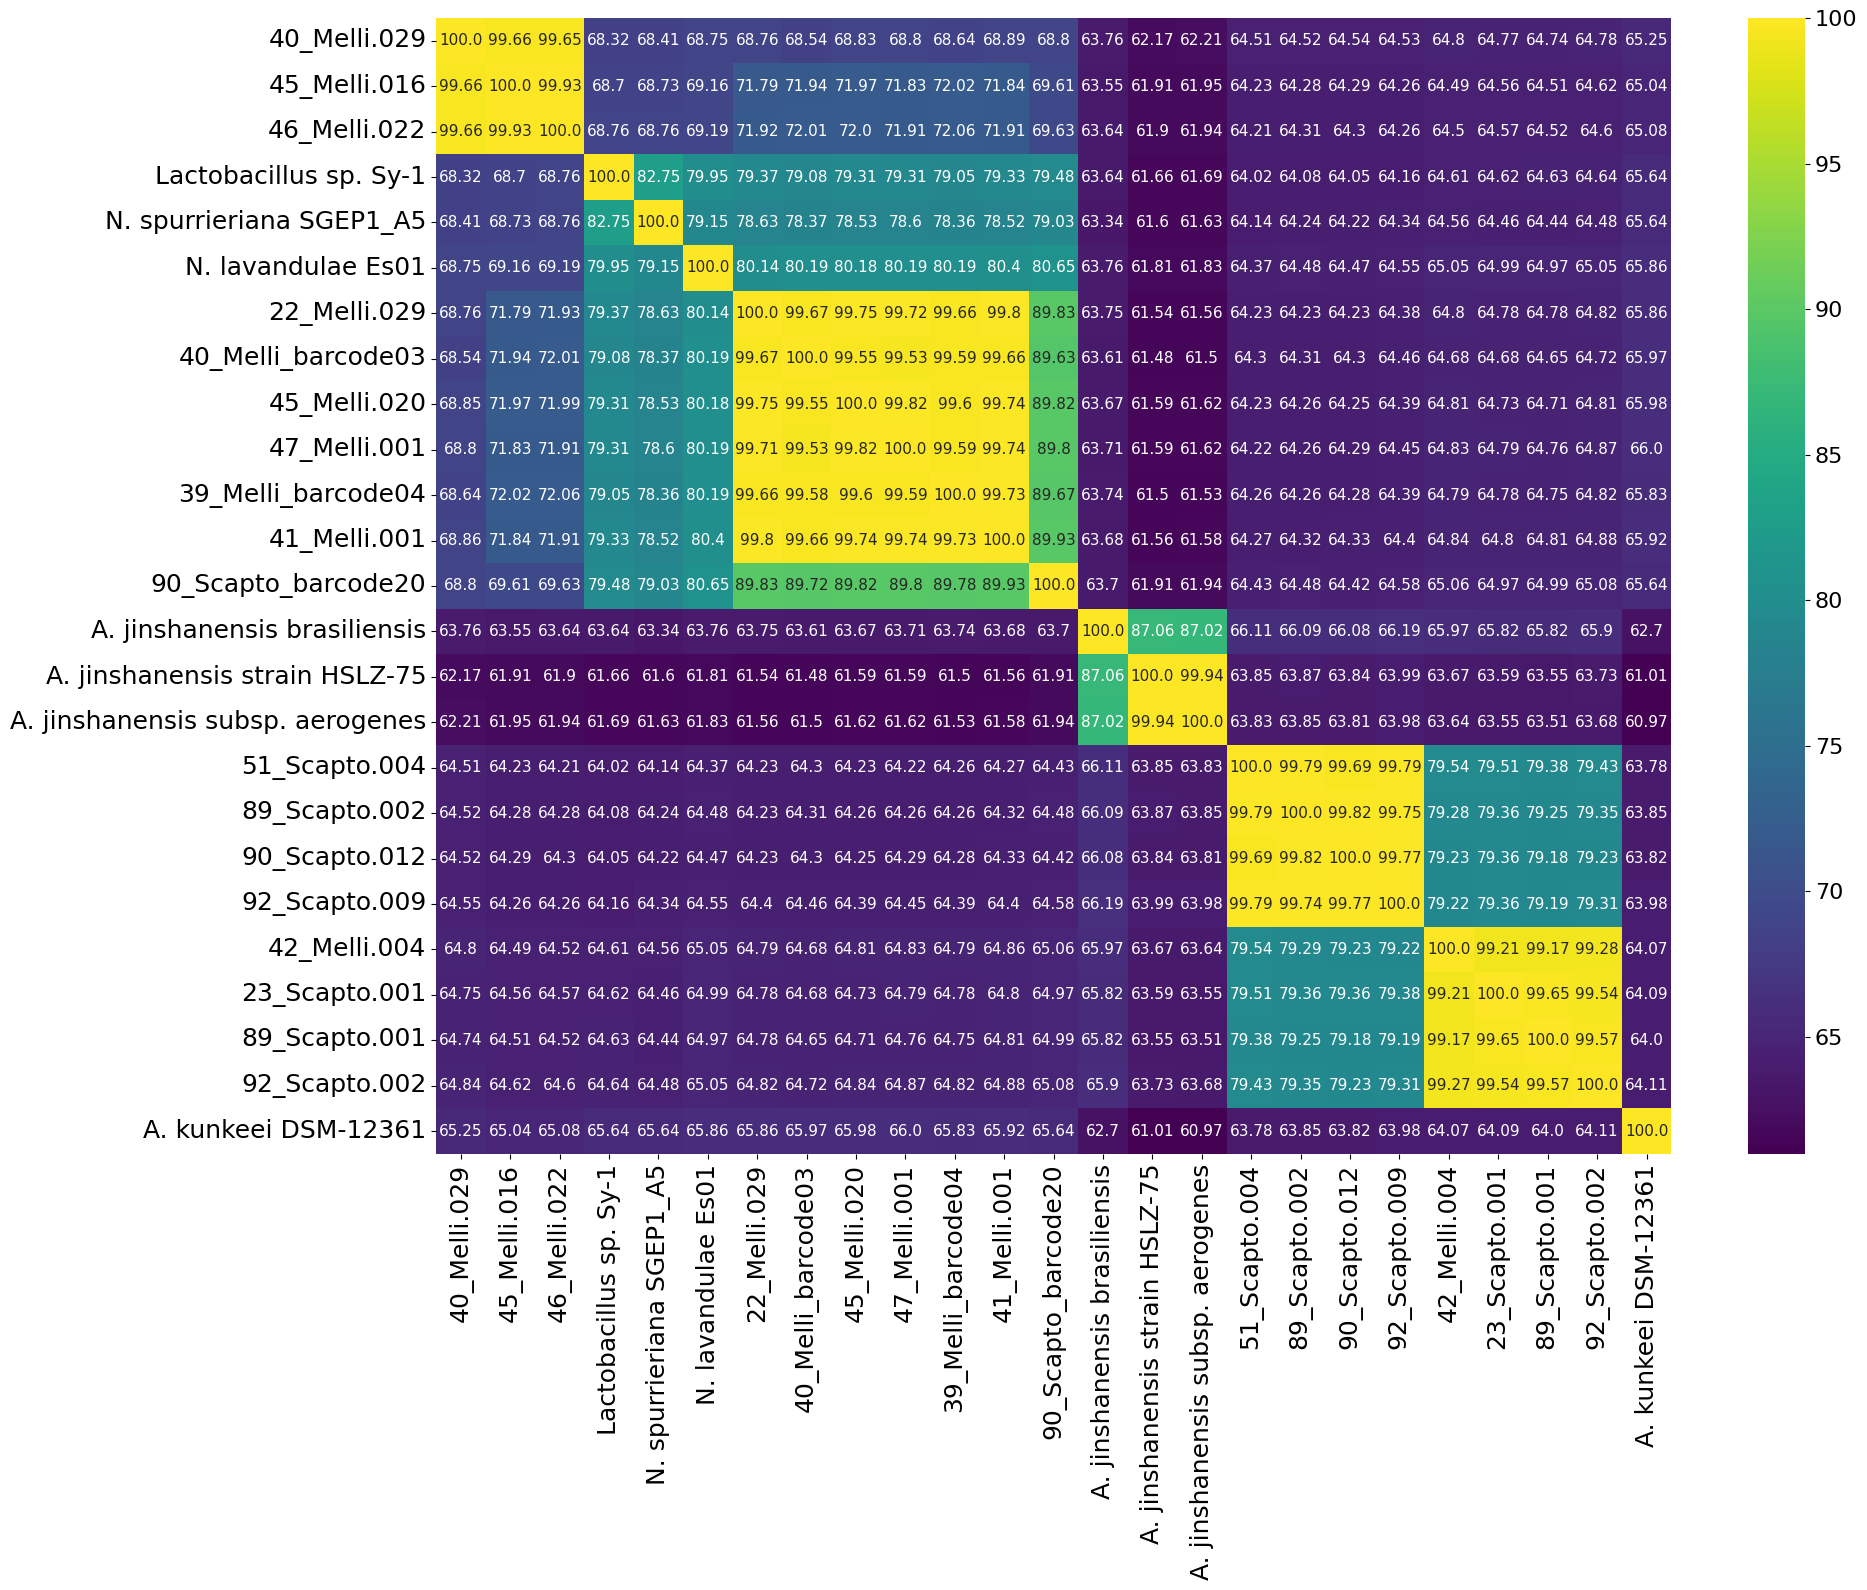

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

annot = matriz_aai.round(2).astype(str)
annot[matriz_aai == 0] = ""

# Figure size
plt.figure(figsize=(20, 16))

# Heatmap with seaborn
ax=sns.heatmap(matriz_aai, annot=annot, fmt="", cmap="viridis", cbar=True, annot_kws={"size": 11})

# Titles and legends
plt.title("", fontsize=16)
plt.xlabel("", fontsize=18)
plt.ylabel("", fontsize=18)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=16)
# Show the heatmap
plt.tight_layout()
# save into a svg
plt.savefig("heatmap_aai.svg", format="svg")
plt.show()

In [12]:
# Define groups
groups = {
    "Clade_1": [0, 1,2],
    "Clade_2-barcode20": [6,7,8,9,10,11],
    "Clade_2+barcode20": [6,7,8,9,10,11,12],
    "Clade_3": [16,17,18,19],
    "Clade_4": [20,21,22,23],
    "Nicoliela+Sp1":[3,4,5],
    "Nicoliela":[4,5],
    "Acetilactobacillus":[13,14,15]
}

In [13]:
import numpy as np
import pandas as pd
from itertools import combinations
# Compute mean, std and var
results_within = {}
for group_name, indices in groups.items():
    submatrix = matriz_aai.iloc[indices, indices]
    results_within[group_name] = {
        "mean": submatrix.values.mean(),
        "std_dev": submatrix.values.std(),
        "var": submatrix.values.var()
    }

# Compute the mean, std and var between groups
results_between = {}
for (group_name_1, indices_1), (group_name_2, indices_2) in combinations(groups.items(), 2):
    submatrix = matriz_aai.iloc[indices_1, indices_2]
    key = f"{group_name_1} vs {group_name_2}"
    results_between[key] = {
        "mean": submatrix.values.mean(),
        "std_dev": submatrix.values.std(),
        "var": submatrix.values.var()
    }

print("The metrics for the AAI index")
# MShow the results
print("The mean, std and var in groups:")
print(pd.DataFrame(results_within).T)

print("\nThe mean, std and var between groupss:")
print(pd.DataFrame(results_between).T)

The metrics for the AAI index
The mean, std and var in groups:
                         mean    std_dev         var
Clade_1             99.833184   0.157752    0.024886
Clade_2-barcode20   99.730294   0.144341    0.020834
Clade_2+barcode20   97.303112   4.276967   18.292447
Clade_3             99.826525   0.106231    0.011285
Clade_4             99.550401   0.307344    0.094460
Nicoliela+Sp1       87.079044   9.222619   85.056707
Nicoliela           89.577149  10.422851  108.635823
Acetilactobacillus  94.226741   6.428474   41.325272

The mean, std and var between groupss:
                                              mean   std_dev        var
Clade_1 vs Clade_2-barcode20             70.871156  1.506491   2.269514
Clade_1 vs Clade_2+barcode20             70.653446  1.500302   2.250907
Clade_1 vs Clade_3                       64.351595  0.124118   0.015405
Clade_1 vs Clade_4                       64.621969  0.113487   0.012879
Clade_1 vs Nicoliela+Sp1                 68.755613  0.272229

In [14]:
import sys
print(sys.version)

3.9.19 (main, May  6 2024, 19:43:03) 
[GCC 11.2.0]


In [15]:
import seaborn
print(seaborn.__version__)

0.13.2


In [16]:
import matplotlib
print(matplotlib.__version__)

3.9.0
